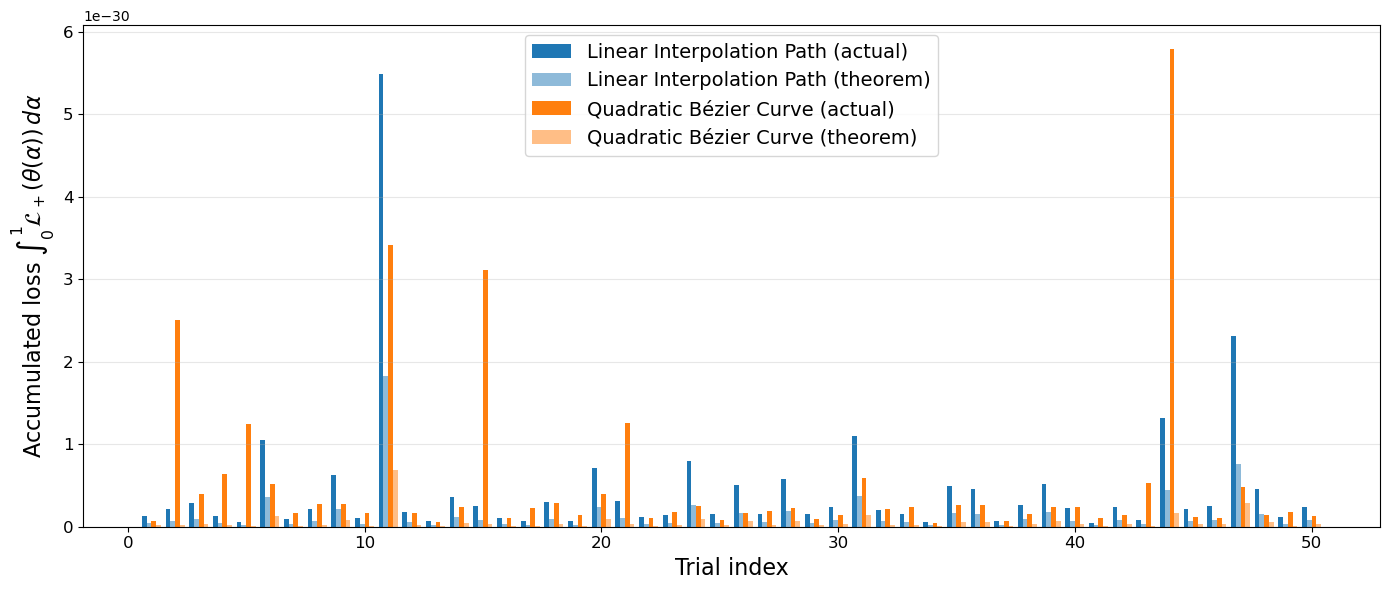

Mean interpolation accumulated loss, numerical: 4.495923734337947e-31
Mean interpolation accumulated loss, formula: 1.5011403208716632e-31
Mean Bézier accumulated loss, numerical: 5.43476108881086e-31
Mean Bézier accumulated loss, formula: 5.629276203268738e-32

Max absolute error, interpolation: 3.6658637247945785e-30
Max absolute error, Bézier: 5.6256228594407536e-30

Fraction Bézier < interpolation, numerical: 0.58
Fraction Bézier < interpolation, formula: 1.0


In [34]:
# Multi task
# feature alignment controlled by rho; task alignment controlled by tau
# compares numerical integrated loss with theorem closed-form loss

import numpy as np
import matplotlib.pyplot as plt


def pinv(A, rcond=1e-12):
    return np.linalg.pinv(A, rcond=rcond)


def task_loss(theta, X, Y):
    return np.linalg.norm(theta @ X - Y) ** 2


def multitask_loss(theta, X1, Y1, X2, Y2):
    return (
        task_loss(theta, X1, Y1)
        + task_loss(theta, X2, Y2)
    )


def integrate_loss(losses, alphas):
    # np.trapezoid is preferred in newer NumPy versions.
    # np.trapz is kept here for broader compatibility.
    return np.trapz(losses, alphas)


def generate_instance(
    d=100,
    n=10,
    seed=None,
    rho=0.0,
    tau=0.0,
):
    rng = np.random.default_rng(seed)

    # Feature matrices: alignment controlled by rho
    X1 = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(d, n),
    )

    Z = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(d, n),
    )

    X2 = (
        rho * X1
        + np.sqrt(1 - rho**2) * Z
    )

    # Ground-truth models: task alignment controlled by tau
    theta1_true = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(1, d),
    )

    W = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(1, d),
    )

    theta2_true = (
        tau * theta1_true
        + np.sqrt(1 - tau**2) * W
    )

    Y1 = theta1_true @ X1
    Y2 = theta2_true @ X2

    return X1, X2, Y1, Y2


def compute_paths(
    d=100,
    n=10,
    seed=0,
    num_grid=400,
    rho=0.0,
    tau=0.0,
):
    X1, X2, Y1, Y2 = generate_instance(
        d=d,
        n=n,
        seed=seed,
        rho=rho,
        tau=tau,
    )

    theta1 = Y1 @ pinv(X1)
    theta2 = Y2 @ pinv(X2)

    S = X1 @ X1.T + X2 @ X2.T

    theta_star = (
        (5 / 2)
        * (Y1 @ X1.T + Y2 @ X2.T)
        @ pinv(S)
        - (3 / 4) * theta1
        - (3 / 4) * theta2
    )

    alphas = np.linspace(0, 1, num_grid)

    interp_losses = []
    merged_losses = []

    for alpha in alphas:
        theta_interp = (
            alpha * theta1
            + (1 - alpha) * theta2
        )

        theta_merged = (
            alpha**2 * theta1
            + 2 * alpha * (1 - alpha) * theta_star
            + (1 - alpha)**2 * theta2
        )

        interp_losses.append(
            multitask_loss(
                theta_interp,
                X1, Y1,
                X2, Y2,
            )
        )

        merged_losses.append(
            multitask_loss(
                theta_merged,
                X1, Y1,
                X2, Y2,
            )
        )

    interp_losses = np.array(interp_losses)
    merged_losses = np.array(merged_losses)

    # Numerical integration of the actually computed squared loss curves
    interp_integral_num = integrate_loss(interp_losses, alphas)
    merged_integral_num = integrate_loss(merged_losses, alphas)

    # Theorem closed-form expressions
    A = theta1 @ X2 - Y2
    B = theta2 @ X1 - Y1

    interp_integral_formula = (
        (1 / 3) * np.linalg.norm(A) ** 2
        + (1 / 3) * np.linalg.norm(B) ** 2
    )

    merged_integral_formula = (
        (1 / 8) * np.linalg.norm(A) ** 2
        + (1 / 8) * np.linalg.norm(B) ** 2
    )

    return (
        alphas,
        interp_losses,
        merged_losses,
        interp_integral_num,
        merged_integral_num,
        interp_integral_formula,
        merged_integral_formula,
    )


# ============================================================
# Parameters
# ============================================================

d = 100
n = 10
num_trials = 50
num_grid = 400

rho = 1  # rho=0 means independent X1, X2; rho=1 means X2=X1
tau = 1  # tau=0 means unrelated ground-truth models; tau=1 means identical ground-truth models

X_distribution = rf"$X_2=\rho X_1+\sqrt{{1-\rho^2}}Z$, $\rho={rho}$"
task_similarity = rf"$\theta_2^{{\mathrm{{true}}}}=\tau\theta_1^{{\mathrm{{true}}}}+\sqrt{{1-\tau^2}}W$, $\tau={tau}$"


# ============================================================
# Run trials
# ============================================================

interp_integrals_num = []
merged_integrals_num = []

interp_integrals_formula = []
merged_integrals_formula = []

for seed in range(num_trials):
    (
        alphas,
        interp_losses,
        merged_losses,
        interp_integral_num,
        merged_integral_num,
        interp_integral_formula,
        merged_integral_formula,
    ) = compute_paths(
        d=d,
        n=n,
        seed=seed,
        num_grid=num_grid,
        rho=rho,
        tau=tau,
    )

    interp_integrals_num.append(interp_integral_num)
    merged_integrals_num.append(merged_integral_num)

    interp_integrals_formula.append(interp_integral_formula)
    merged_integrals_formula.append(merged_integral_formula)


interp_integrals_num = np.array(interp_integrals_num)
merged_integrals_num = np.array(merged_integrals_num)

interp_integrals_formula = np.array(interp_integrals_formula)
merged_integrals_formula = np.array(merged_integrals_formula)


# ============================================================
# Plot
# ============================================================

trial_indices = np.arange(1, num_trials + 1)
width = 0.2

plt.figure(figsize=(14, 6))

plt.bar(
    trial_indices - 1.5 * width,
    interp_integrals_num,
    width=width,
    label="Linear Interpolation Path (actual)",
    color="tab:blue",
    alpha=1,
)

plt.bar(
    trial_indices - 0.5 * width,
    interp_integrals_formula,
    width=width,
    label="Linear Interpolation Path (theorem)",
    color="tab:blue",
    alpha=0.5,
)

plt.bar(
    trial_indices + 0.5 * width,
    merged_integrals_num,
    width=width,
    label="Quadratic Bézier Curve (actual)",
    color="tab:orange",
    alpha=1,
)

plt.bar(
    trial_indices + 1.5 * width,
    merged_integrals_formula,
    width=width,
    label="Quadratic Bézier Curve (theorem)",
    color="tab:orange",
    alpha=0.5,
)

plt.xlabel("Trial index", fontsize=16)
plt.ylabel(
    r"Accumulated loss $\int_0^1 \mathcal{L}_+(\theta(\alpha))\,d\alpha$",
    fontsize=16,
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14,
           loc="best")   
# plt.legend(fontsize=14,
#            loc="upper right",
#     bbox_to_anchor=(0.9, 1),) 

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Numerical summary
# ============================================================

print("Mean interpolation accumulated loss, numerical:",
      interp_integrals_num.mean())

print("Mean interpolation accumulated loss, formula:",
      interp_integrals_formula.mean())

print("Mean Bézier accumulated loss, numerical:",
      merged_integrals_num.mean())

print("Mean Bézier accumulated loss, formula:",
      merged_integrals_formula.mean())

print()

print("Max absolute error, interpolation:",
      np.max(np.abs(interp_integrals_num - interp_integrals_formula)))

print("Max absolute error, Bézier:",
      np.max(np.abs(merged_integrals_num - merged_integrals_formula)))

print()

print("Fraction Bézier < interpolation, numerical:",
      np.mean(merged_integrals_num < interp_integrals_num))

print("Fraction Bézier < interpolation, formula:",
      np.mean(merged_integrals_formula < interp_integrals_formula))

||A|| = 2.9406505148178845e-16
||B|| = 2.9406505148178845e-16
||A|| = 1.354205301155735e-15
||B|| = 1.354205301155735e-15
||A|| = 2.5676251558357494e-16
||B|| = 2.5676251558357494e-16
||A|| = 2.7590284712540662e-16
||B|| = 2.7590284712540662e-16
||A|| = 3.5603799494368843e-16
||B|| = 3.5603799494368843e-16
||A|| = 2.29881952564056e-16
||B|| = 2.29881952564056e-16
||A|| = 2.978929865793755e-16
||B|| = 2.978929865793755e-16
||A|| = 1.1632805222743017e-15
||B|| = 1.1632805222743017e-15
||A|| = 3.2850001856384624e-16
||B|| = 3.2850001856384624e-16
||A|| = 3.580620640298173e-16
||B|| = 3.580620640298173e-16
||A|| = 1.255279517633527e-15
||B|| = 1.255279517633527e-15
||A|| = 6.61359237228119e-16
||B|| = 6.61359237228119e-16
||A|| = 3.4210824021038577e-16
||B|| = 3.4210824021038577e-16
||A|| = 4.115647441276492e-16
||B|| = 4.115647441276492e-16
||A|| = 1.5412947308735548e-16
||B|| = 1.5412947308735548e-16
||A|| = 3.289211373961135e-16
||B|| = 3.289211373961135e-16
||A|| = 4.714875012456817e-1

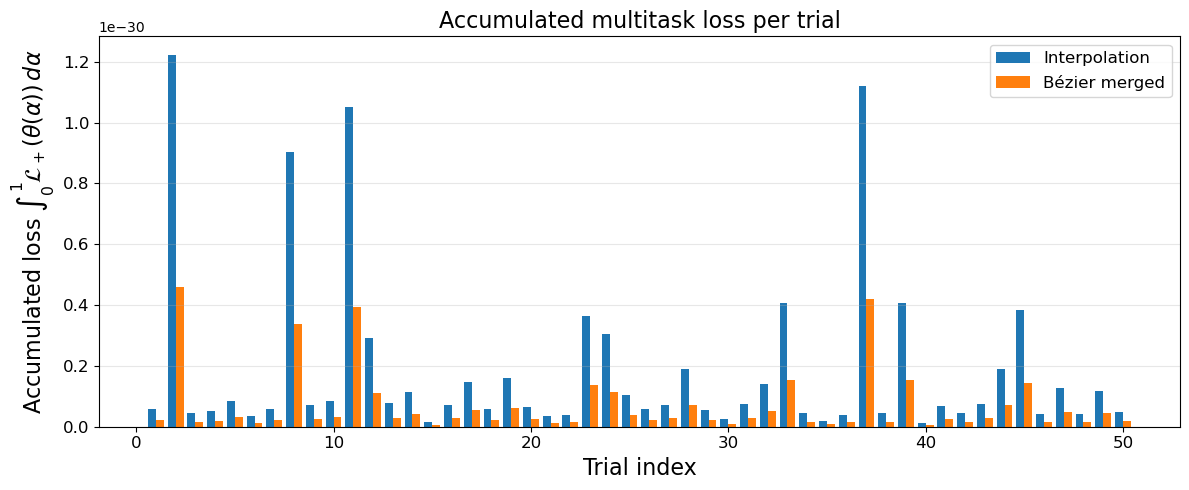

Mean interpolation accumulated loss: 1.8710608934214794e-31
Mean Bézier accumulated loss: 7.016478350330547e-32
Fraction Bézier < interpolation: 1.0


In [54]:
# # Multi task 

# misaligned data and theta

import numpy as np
import matplotlib.pyplot as plt


def pinv(A, rcond=1e-12):
    return np.linalg.pinv(A, rcond=rcond)


def task_loss(theta, X, Y):
    return np.linalg.norm(theta @ X - Y) ** 2

def multitask_loss(theta, X1, Y1, X2, Y2):
    return (
        task_loss(theta, X1, Y1)
        + task_loss(theta, X2, Y2)
    )


def generate_instance(
    d=100,
    n=10,
    seed=None,
    rho=0,
):
    rng = np.random.default_rng(seed)

    X1 = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(d, n),
    )

    Z = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(d, n),
    )

    X2 = (
        rho * X1
        + np.sqrt(1 - rho**2) * Z
    )

    theta_similarity = 1

    theta1_true = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(1, d),
    )

    theta_noise = rng.normal(
        0,
        1 / np.sqrt(d),
        size=(1, d),
    )

    theta2_true = (
        theta_similarity * theta1_true
        + np.sqrt(1 - theta_similarity**2) * theta_noise
    )

    Y1 = theta1_true @ X1
    Y2 = theta2_true @ X2

    return X1, X2, Y1, Y2


def compute_paths(d=100, n=10, seed=0, num_grid=400, rho=0):
    X1, X2, Y1, Y2 = generate_instance(
        d=d,
        n=n,
        seed=seed,
        rho=rho,
    )

    theta1 = Y1 @ pinv(X1)
    theta2 = Y2 @ pinv(X2)

    S = X1 @ X1.T + X2 @ X2.T

    theta_star = (
        (5 / 2)
        * (Y1 @ X1.T + Y2 @ X2.T)
        @ pinv(S)
        - (3 / 4) * theta1
        - (3 / 4) * theta2
    )

    alphas = np.linspace(0, 1, num_grid)

    interp_losses = []
    merged_losses = []

    for alpha in alphas:

        theta_interp = (
            alpha * theta1
            + (1 - alpha) * theta2
        )

        theta_merged = (
            alpha**2 * theta1
            + 2 * alpha * (1 - alpha) * theta_star
            + (1 - alpha)**2 * theta2
        )

        interp_losses.append(
            multitask_loss(
                theta_interp,
                X1, Y1,
                X2, Y2
            )
        )

        merged_losses.append(
            multitask_loss(
                theta_merged,
                X1, Y1,
                X2, Y2
            )
        )

    interp_losses = np.array(interp_losses)
    merged_losses = np.array(merged_losses)

    A = theta1 @ X2 - Y2
    B = theta2 @ X1 - Y1
    print("||A|| =", np.linalg.norm(A))
    print("||B|| =", np.linalg.norm(B))

    interp_integral = (
        (1 / 3) * np.linalg.norm(A) ** 2
        + (1 / 3) * np.linalg.norm(B) ** 2
    )

    merged_integral = (
        (1 / 8) * np.linalg.norm(A) ** 2
        + (1 / 8) * np.linalg.norm(B) ** 2
    )

    return (
        alphas,
        interp_losses,
        merged_losses,
        interp_integral,
        merged_integral,
    )




d = 100
n = 10
num_trials = 50
num_grid = 400
rho = 1  # rho=0 means independent X1, X2
theta_similarity = 1

X_distribution = r"$X_i \sim N(0,1/d)$"
task_similarity = rf"$X_2=\rho X_1+\sqrt{{1-\rho^2}}Z$, $\rho={rho}$"

# ============================================================
# Run trials and compute accumulated losses
# ============================================================

interp_integrals = []
merged_integrals = []

for _ in range(num_trials):
    (
        alphas,
        interp_losses,
        merged_losses,
        interp_integral,
        merged_integral,
    ) = compute_paths(
        d=d,
        n=n,
        seed=None,
        num_grid=num_grid,
        rho=rho,
    )

    interp_integrals.append(interp_integral)
    merged_integrals.append(merged_integral)

interp_integrals = np.array(interp_integrals)
merged_integrals = np.array(merged_integrals)

trial_indices = np.arange(1, num_trials + 1)
width = 0.4

plt.figure(figsize=(12, 5))

plt.bar(
    trial_indices - width / 2,
    interp_integrals,
    width=width,
    label="Interpolation",
)

plt.bar(
    trial_indices + width / 2,
    merged_integrals,
    width=width,
    label="Bézier merged",
)

plt.xlabel("Trial index",fontsize=16)
plt.ylabel(
    r"Accumulated loss $\int_0^1 \mathcal{L}_+(\theta(\alpha))\,d\alpha$"
,fontsize=16,)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title(
    "Accumulated multitask loss per trial",fontsize=16
)

plt.legend(fontsize=12)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================
# Numerical summary
# ============================================================


print("Mean interpolation accumulated loss:",
      interp_integrals.mean())

print("Mean Bézier accumulated loss:",
      merged_integrals.mean())

print("Fraction Bézier < interpolation:",
      np.mean(merged_integrals < interp_integrals))


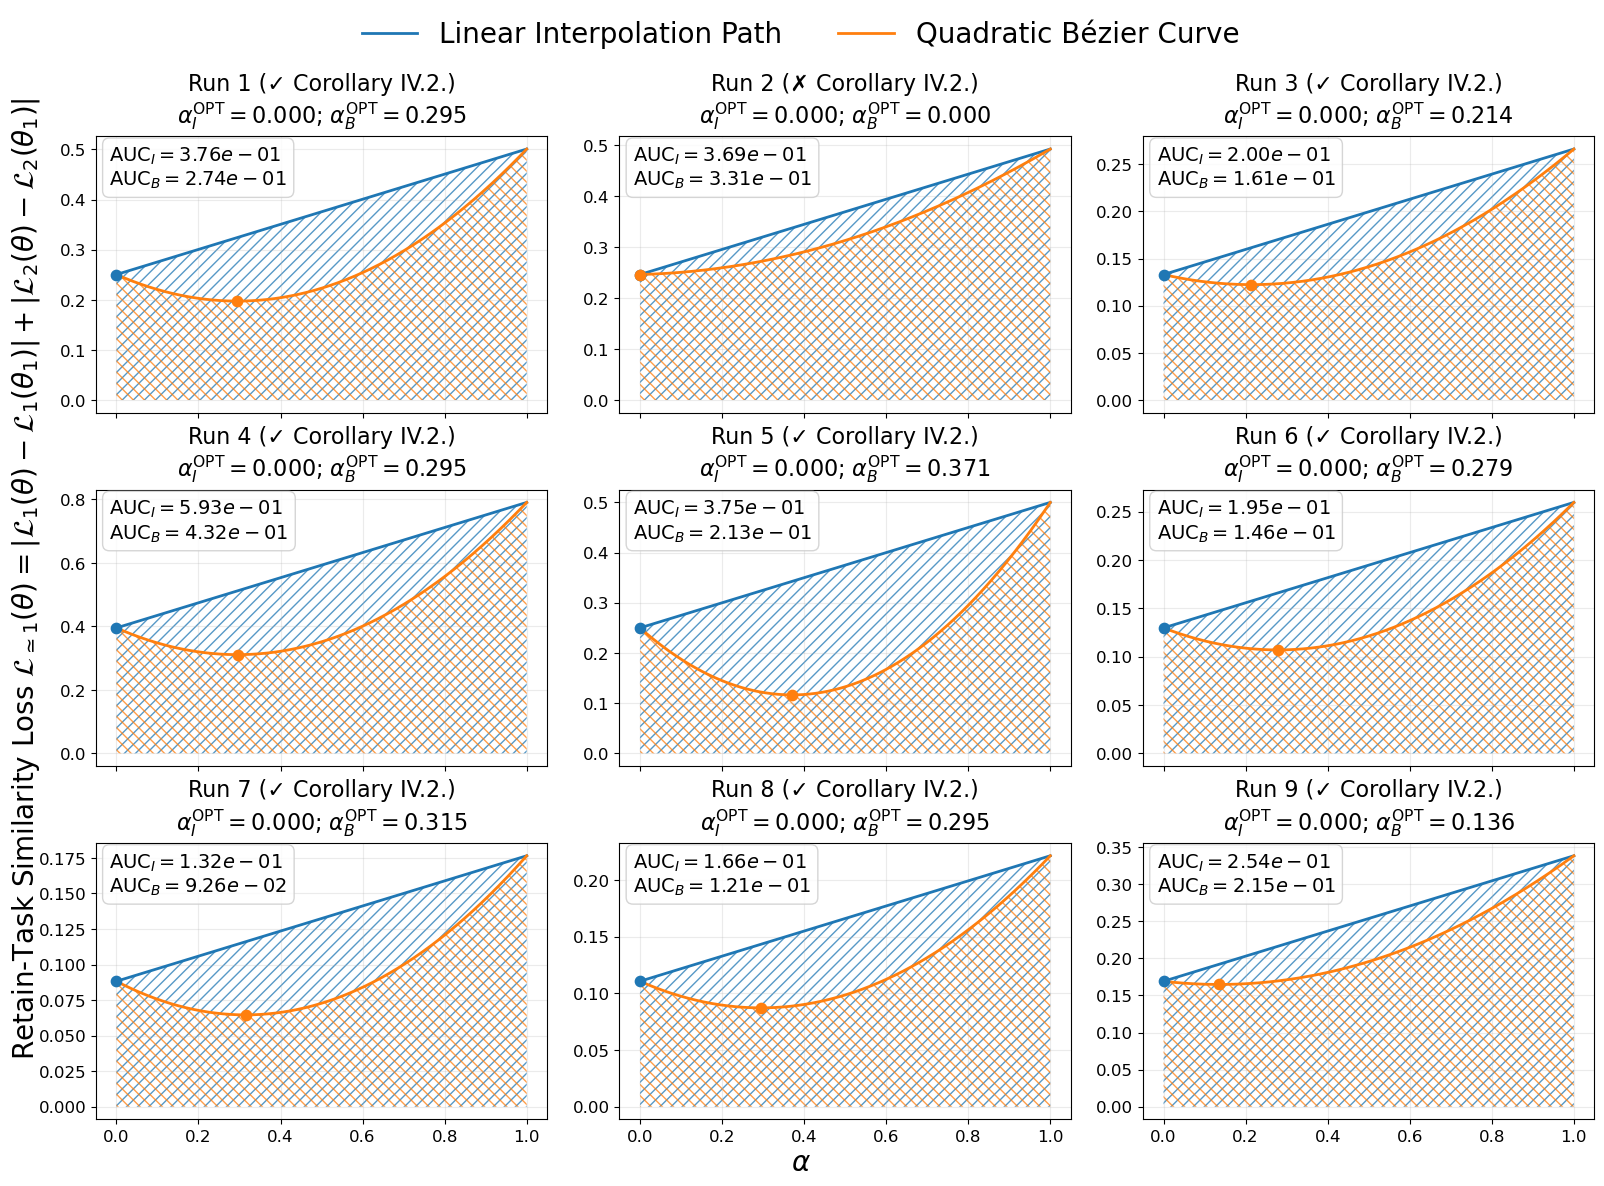


Condition summary:

Trial  1: True   min LHS=2.205e-01   RHS=2.504e-01   alpha_cond=0.624
Trial  2: False   min LHS=2.460e-01   RHS=2.460e-01   alpha_cond=1.000
Trial  3: True   min LHS=1.284e-01   RHS=1.331e-01   alpha_cond=0.722
Trial  4: True   min LHS=3.475e-01   RHS=3.951e-01   alpha_cond=0.623
Trial  5: True   min LHS=1.608e-01   RHS=2.499e-01   alpha_cond=0.533
Trial  6: True   min LHS=1.175e-01   RHS=1.298e-01   alpha_cond=0.643
Trial  7: True   min LHS=7.421e-02   RHS=8.823e-02   alpha_cond=0.599
Trial  8: True   min LHS=9.744e-02   RHS=1.107e-01   alpha_cond=0.623
Trial  9: True   min LHS=1.679e-01   RHS=1.692e-01   alpha_cond=0.822


In [54]:
# Machine Unlearning setting 1
# feature alignment controlled by rho; task alignment controlled by tau

import numpy as np
import matplotlib.pyplot as plt


def pinv(A, rcond=1e-12):
    return np.linalg.pinv(A, rcond=rcond)


def generate_instance(d=100, n=10, seed=0, rho=0.0, tau=0.9):
    rng = np.random.default_rng(seed)

    X1 = rng.normal(0, 1 / np.sqrt(d), size=(d, n))
    Z = rng.normal(0, 1 / np.sqrt(d), size=(d, n))

    X2 = rho * X1 + np.sqrt(1 - rho**2) * Z

    theta1_true = rng.normal(0, 1 / np.sqrt(d), size=(1, d))
    noise_direction = rng.normal(0, 1 / np.sqrt(d), size=(1, d))

    theta2_true = (
        tau * theta1_true
        + np.sqrt(1 - tau**2) * noise_direction
    )

    Y1 = theta1_true @ X1
    Y2 = theta2_true @ X2

    return X1, X2, Y1, Y2, theta1_true, theta2_true


def task_loss(theta, X, Y):
    return np.linalg.norm(theta @ X - Y) ** 2


def comparison_objective(theta, theta1, X1, Y1, X2, Y2):
    L1_theta = task_loss(theta, X1, Y1)
    L2_theta = task_loss(theta, X2, Y2)

    L1_theta1 = task_loss(theta1, X1, Y1)
    L2_theta1 = task_loss(theta1, X2, Y2)

    return abs(L1_theta - L1_theta1) + abs(L2_theta - L2_theta1)


def compute_theta_star(X1, X2, Y1, Y2, theta12, theta2, lam=0.9):
    d = X1.shape[0]
    I = np.eye(d)

    M = lam * X1 @ X1.T - X2 @ X2.T

    left = (
        (2 / 3) * (lam * Y1 @ X1.T - Y2 @ X2.T)
        - (1 / 5) * (theta12 + theta2) @ M
    )

    right = 2 * I + (4 / 15) * M

    theta_star = left @ pinv(right)
    return theta_star


def run_experiment(
    d=100,
    n=10,
    seed=None,
    rho=0.0,
    tau=0.9,
    lam=0.9,
    num_grid=10001,
    plot=True,
    verbose=True,
):
    X1, X2, Y1, Y2, theta1_true, theta2_true = generate_instance(
        d=d,
        n=n,
        seed=seed,
        rho=rho,
        tau=tau,
    )

    theta1 = Y1 @ pinv(X1)
    theta2 = Y2 @ pinv(X2)

    X12 = np.concatenate([X1, X2], axis=1)
    Y12 = np.concatenate([Y1, Y2], axis=1)
    theta12 = Y12 @ pinv(X12)

    theta_star = compute_theta_star(
        X1, X2, Y1, Y2, theta12, theta2, lam=lam
    )

    alphas = np.linspace(0, 1, num_grid)

    interp_objectives = []
    merged_objectives = []

    for alpha in alphas:
        theta_interp = (1 - alpha) * theta12 + alpha * theta2

        theta_merged = (
            (1 - alpha) ** 2 * theta12
            + 2 * alpha * (1 - alpha) * theta_star
            + alpha**2 * theta2
        )

        interp_objectives.append(
            comparison_objective(theta_interp, theta1, X1, Y1, X2, Y2)
        )

        merged_objectives.append(
            comparison_objective(theta_merged, theta1, X1, Y1, X2, Y2)
        )

    interp_objectives = np.array(interp_objectives)
    merged_objectives = np.array(merged_objectives)

    idx_interp = np.argmin(interp_objectives)
    idx_merged = np.argmin(merged_objectives)

    alpha_interp_opt = alphas[idx_interp]
    alpha_merged_opt = alphas[idx_merged]

    loss_interp_opt = interp_objectives[idx_interp]
    loss_merged_opt = merged_objectives[idx_merged]

    interp_auc = np.trapz(interp_objectives, alphas)
    merged_auc = np.trapz(merged_objectives, alphas)

    if verbose:
        print("Optimal interpolation model:")
        print(f"  alpha = {alpha_interp_opt:.6f}")
        print(f"  comparison loss = {loss_interp_opt:.8e}")

        print("\nOptimal merged model:")
        print(f"  alpha = {alpha_merged_opt:.6f}")
        print(f"  comparison loss = {loss_merged_opt:.8e}")

        print("\nImprovement:")
        print(f"  interp loss - merged loss = {loss_interp_opt - loss_merged_opt:.8e}")
        print(f"  ratio merged / interp = {loss_merged_opt / loss_interp_opt:.6f}")

        print("\nArea under curves:")
        print(f"  Interpolation AUC = {interp_auc:.8e}")
        print(f"  Merged Bézier AUC = {merged_auc:.8e}")

    if plot:
        plt.figure(figsize=(8, 5))
        plt.rcParams["text.usetex"] = True

        interp_line, = plt.plot(
            alphas,
            interp_objectives,
            linewidth=2,
            label=r"Linear Interpolation Path " + rf"(AUC={interp_auc:.3e})",
        )

        merged_line, = plt.plot(
            alphas,
            merged_objectives,
            linewidth=2,
            label=r"Quadratic Bézier Curve " + rf"(AUC={merged_auc:.3e})",
        )

        plt.fill_between(
            alphas,
            interp_objectives,
            facecolor="none",
            edgecolor=interp_line.get_color(),
            hatch="///",
            linewidth=0.0,
            alpha=0.8,
        )

        plt.fill_between(
            alphas,
            merged_objectives,
            facecolor="none",
            edgecolor=merged_line.get_color(),
            hatch="\\\\\\",
            linewidth=0.0,
            alpha=0.8,
        )

        plt.scatter(
            alpha_interp_opt,
            loss_interp_opt,
            s=90,
            marker="o",
            color=interp_line.get_color(),
            zorder=5,
            label=r"Optimal $\theta_{\mathrm{interp}}^{\mathrm{OPT}}$",
        )

        plt.scatter(
            alpha_merged_opt,
            loss_merged_opt,
            s=90,
            marker="o",
            color=merged_line.get_color(),
            zorder=5,
            label=r"Optimal $\theta_{\mathrm{merged}}^{\mathrm{OPT}}$",
        )

        plt.xlabel(r"$\alpha$")
        plt.ylabel(r"comparison objective to $\theta_1$")
        plt.title("Interpolation vs Bézier merged path")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "alpha_interp_opt": alpha_interp_opt,
        "loss_interp_opt": loss_interp_opt,
        "interp_auc": interp_auc,
        "alpha_merged_opt": alpha_merged_opt,
        "loss_merged_opt": loss_merged_opt,
        "merged_auc": merged_auc,
        "alphas": alphas,
        "interp_objectives": interp_objectives,
        "merged_objectives": merged_objectives,
        "theta1": theta1,
        "theta2": theta2,
        "theta12": theta12,
        "theta_star": theta_star,
        "rho": rho,
        "tau": tau,
        "theta1_true": theta1_true,
        "theta2_true": theta2_true,
        "X1": X1,
        "X2": X2,
        "Y1": Y1,
        "Y2": Y2,
    }


def run_9_trials_compact(
    d=100,
    n=10,
    rho=0.0,
    tau=1,
    lam=0.9,
    num_grid=10001,
    num_trials=9,
    ncols=3,
):
    nrows = int(np.ceil(num_trials / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.4 * ncols, 4.2 * nrows),
        sharex=True,
        sharey=False,
    )

    axes = np.asarray(axes).ravel()
    summary = []

    for trial in range(num_trials):
        result = run_experiment(
            d=d,
            n=n,
            seed=None,
            rho=rho,
            tau=tau,
            lam=lam,
            num_grid=num_grid,
            plot=False,
            verbose=False,
        )

        alphas = result["alphas"]
        interp_objectives = result["interp_objectives"]
        merged_objectives = result["merged_objectives"]

        alpha_interp_opt = result["alpha_interp_opt"]
        loss_interp_opt = result["loss_interp_opt"]
        interp_auc = result["interp_auc"]

        alpha_merged_opt = result["alpha_merged_opt"]
        loss_merged_opt = result["loss_merged_opt"]
        merged_auc = result["merged_auc"]

        theta1 = result["theta1"]
        theta2 = result["theta2"]
        theta_star = result["theta_star"]

        X1 = result["X1"]
        X2 = result["X2"]
        Y1 = result["Y1"]
        Y2 = result["Y2"]

        # -----------------------------------------------------
        # Condition:
        #
        # Check whether there exists alpha in [0,1] such that
        #
        # ||(1-alpha)^2(theta2 X1 - Y1)
        #   + 2 alpha(1-alpha)(theta_star X1 - Y1)||^2
        #
        # + |4 alpha^2(1-alpha)^2 ||theta_star X2 - Y2||^2
        #   - ||theta1 X2 - Y2||^2|
        #
        # < ||theta1 X2 - Y2||^2.
        # -----------------------------------------------------

        A = theta2 @ X1 - Y1
        E1 = theta_star @ X1 - Y1
        E2 = theta_star @ X2 - Y2
        R21 = theta1 @ X2 - Y2

        rhs = np.linalg.norm(R21) ** 2

        condition_values = []

        for alpha in alphas:
            first_term = np.linalg.norm(
                (1 - alpha) ** 2 * A
                + 2 * alpha * (1 - alpha) * E1
            ) ** 2

            second_term = abs(
                4
                * alpha**2
                * (1 - alpha) ** 2
                * np.linalg.norm(E2) ** 2
                - rhs
            )

            condition_values.append(first_term + second_term)

        condition_values = np.array(condition_values)

        min_condition_value = np.min(condition_values)
        alpha_condition_opt = alphas[np.argmin(condition_values)]

        cond = min_condition_value < rhs

        ax = axes[trial]

        interp_line, = ax.plot(
            alphas,
            interp_objectives,
            linewidth=2.0,
            label=r"Linear Interpolation Path",
        )

        merged_line, = ax.plot(
            alphas,
            merged_objectives,
            linewidth=2.0,
            label=r"Quadratic Bézier Curve",
        )

        ax.fill_between(
            alphas,
            interp_objectives,
            facecolor="none",
            edgecolor=interp_line.get_color(),
            hatch="///",
            linewidth=0.0,
            alpha=0.75,
        )

        ax.fill_between(
            alphas,
            merged_objectives,
            facecolor="none",
            edgecolor=merged_line.get_color(),
            hatch="\\\\\\",
            linewidth=0.0,
            alpha=0.75,
        )

        ax.scatter(
            alpha_interp_opt,
            loss_interp_opt,
            s=55,
            color=interp_line.get_color(),
            zorder=5,
        )

        ax.scatter(
            alpha_merged_opt,
            loss_merged_opt,
            s=55,
            color=merged_line.get_color(),
            zorder=5,
        )

        condition_tag = "✓ Corollary IV.2." if cond else "✗ Corollary IV.2."

        ax.set_title(
            (
                rf"Run {trial + 1} ({condition_tag})"
                "\n"
                rf"$\alpha_I^{{\mathrm{{OPT}}}}={alpha_interp_opt:.3f}$; "
                rf"$\alpha_B^{{\mathrm{{OPT}}}}={alpha_merged_opt:.3f}$"
            ),
            fontsize=16,
            pad=10,
        )

        ax.text(
            0.03,
            0.97,
            (
                rf"$\mathrm{{AUC}}_I={interp_auc:.2e}$"
                "\n"
                rf"$\mathrm{{AUC}}_B={merged_auc:.2e}$"
                # "\n"
                # rf"$\alpha_C^*={alpha_condition_opt:.3f}$"
            ),
            transform=ax.transAxes,
            fontsize=14,
            va="top",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                alpha=0.82,
                edgecolor="0.8",
            ),
        )

        ax.tick_params(axis="both", labelsize=12)
        ax.grid(True, alpha=0.25)

        summary.append({
            "trial": trial + 1,
            "condition": cond,
            "min_condition_value": min_condition_value,
            "rhs": rhs,
            "alpha_condition_opt": alpha_condition_opt,
            "alpha_interp_opt": alpha_interp_opt,
            "alpha_merged_opt": alpha_merged_opt,
            "interp_auc": interp_auc,
            "merged_auc": merged_auc,
        })

    for j in range(num_trials, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    # fig.suptitle(
    #     rf"Interpolation vs Bézier merged path over 9 random trials "
    #     rf"($\rho={rho}$, $\tau={tau}$, $\lambda={lam}$)",
    #     fontsize=24,
    #     y=0.975,
    # )

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.962),
        ncol=2,
        frameon=False,
        fontsize=20,
    )

    fig.supxlabel(r"$\alpha$", fontsize=20, y=0.025)

    fig.supylabel(
        r"Retain-Task Similarity Loss $\mathcal{L}_{\simeq 1}(\theta) = |\mathcal{L}_1(\theta)-\mathcal{L}_1(\theta_1)| + |\mathcal{L}_2(\theta)-\mathcal{L}_2(\theta_1)|$",
        fontsize=20,
        x=0.012,
    )

    fig.subplots_adjust(
        left=0.065,
        right=0.99,
        bottom=0.07,
        top=0.85,
        wspace=0.16,
        hspace=0.28,
    )

    plt.savefig(
        "/home/duantu/Desktop/unlearning_setting1_misaligned.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("\nCondition summary:\n")

    for row in summary:
        print(
            f"Trial {row['trial']:2d}: "
            f"{row['condition']}   "
            f"min LHS={row['min_condition_value']:.3e}   "
            f"RHS={row['rhs']:.3e}   "
            f"alpha_cond={row['alpha_condition_opt']:.3f}"
        )

    return summary


summary = run_9_trials_compact(
    d=100,
    n=10,
    rho=1,
    tau=0,
    lam=0.9,
    num_grid=10001,
    num_trials=9,
    ncols=3,
)

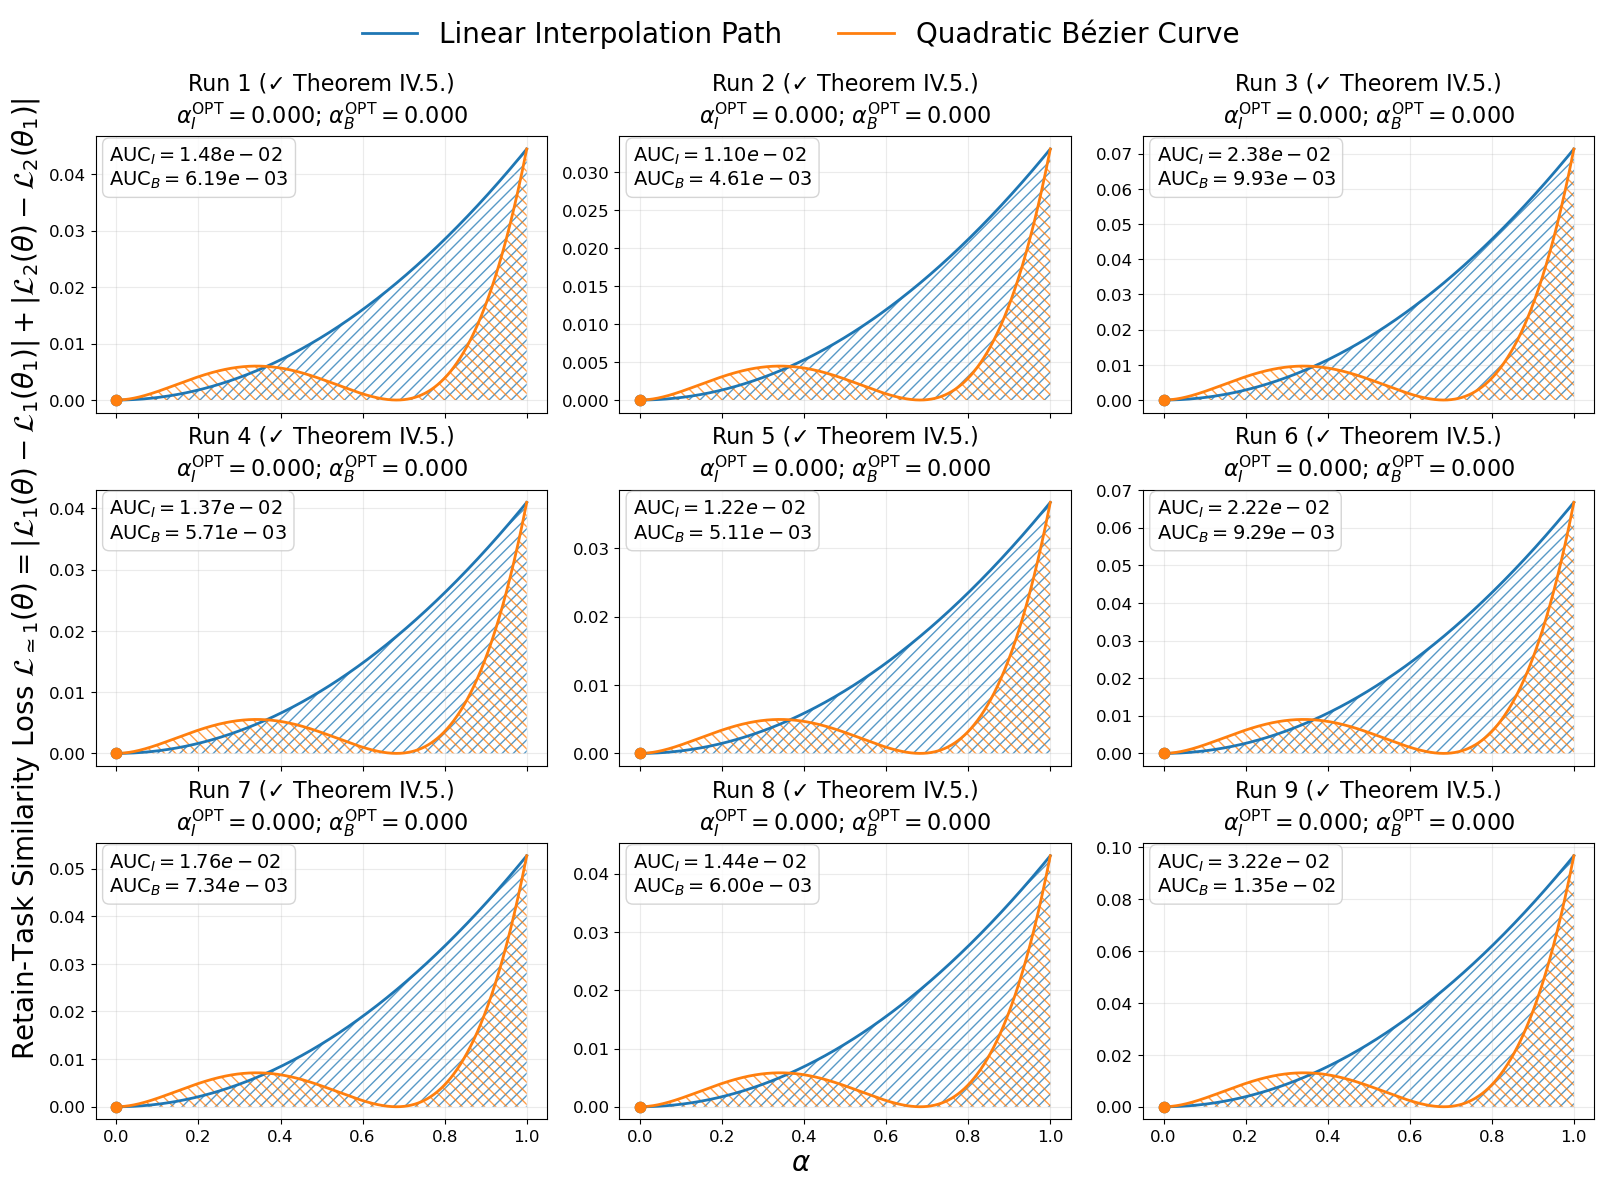


Condition summary:

Trial  1: True   
Trial  2: True   
Trial  3: True   
Trial  4: True   
Trial  5: True   
Trial  6: True   
Trial  7: True   
Trial  8: True   
Trial  9: True   


In [76]:
# Machine Unlearning Setting 2
# feature alignment controlled by rho; task alignment controlled by tau

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


def pinv(A, rcond=1e-12):
    return np.linalg.pinv(A, rcond=rcond)


def generate_instance(d=100, n=10, seed=None, rho=0.0, tau=0.9):
    rng = np.random.default_rng(seed)

    X1 = rng.normal(0, 1 / np.sqrt(d), size=(d, n))
    Z = rng.normal(0, 1 / np.sqrt(d), size=(d, n))
    X2 = rho * X1 + np.sqrt(1 - rho**2) * Z

    theta1_true = rng.normal(0, 1 / np.sqrt(d), size=(1, d))
    noise_direction = rng.normal(0, 1 / np.sqrt(d), size=(1, d))
    theta2_true = tau * theta1_true + np.sqrt(1 - tau**2) * noise_direction

    Y1 = theta1_true @ X1
    Y2 = theta2_true @ X2

    return X1, X2, Y1, Y2, theta1_true, theta2_true


def task_loss(theta, X, Y):
    return np.linalg.norm(theta @ X - Y) ** 2


def comparison_objective(theta, theta1, X1, Y1, X2, Y2):
    L1_theta = task_loss(theta, X1, Y1)
    L2_theta = task_loss(theta, X2, Y2)
    L1_theta1 = task_loss(theta1, X1, Y1)
    L2_theta1 = task_loss(theta1, X2, Y2)
    return abs(L1_theta - L1_theta1) + abs(L2_theta - L2_theta1)


def compute_theta_bar(X1, X2, Y1, Y2, lambda1=0.5, lambda2=0.5, mu=1.0):
    d = X1.shape[0]
    I = np.eye(d)
    left = lambda1 * Y1 @ X1.T - lambda2 * Y2 @ X2.T
    right = lambda1 * X1 @ X1.T - lambda2 * X2 @ X2.T + mu * I
    return left @ pinv(right)


def accumulated_merged_loss_closed_form(theta_star_flat, theta_bar, theta1, X1, Y1, X2, Y2):
    theta_star = theta_star_flat.reshape(1, -1)

    R1 = theta_bar @ X1 - Y1
    R2 = theta_bar @ X2 - Y2
    E1 = theta_star @ X1 - Y1
    E2 = theta_star @ X2 - Y2
    D = task_loss(theta1, X2, Y2)

    def squared_integral_term(R, E):
        R_norm_sq = np.linalg.norm(R) ** 2
        E_norm_sq = np.linalg.norm(E) ** 2
        inner = float(np.sum(R * E))
        return (
            35 * R_norm_sq**2
            + 10 * R_norm_sq * E_norm_sq
            + 35 * R_norm_sq * inner
            + 8 * E_norm_sq**2
            + 20 * E_norm_sq * inner
            + 20 * inner**2
        )

    integral_L1_sq = squared_integral_term(R1, E1) / 315
    integral_L2_sq = squared_integral_term(R2, E2) / 315
    integral_L2 = (
        (1 / 5) * np.linalg.norm(R2) ** 2
        + (2 / 15) * np.linalg.norm(E2) ** 2
        + (1 / 5) * float(np.sum(R2 * E2))
    )

    return integral_L1_sq + integral_L2_sq - 2 * D * integral_L2 + D**2


def compute_theta_star(X1, X2, Y1, Y2, theta12, theta_bar, theta1):
    initial_guesses = [theta1, theta_bar, theta12, 0.5 * (theta12 + theta_bar)]
    best_result = None

    for init in initial_guesses:
        result = minimize(
            accumulated_merged_loss_closed_form,
            init.ravel(),
            args=(theta_bar, theta1, X1, Y1, X2, Y2),
            method="BFGS",
            options={"gtol": 1e-8, "maxiter": 2000},
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    if not best_result.success:
        print("Warning: theta_star optimization did not fully converge.")
        print(best_result.message)

    return best_result.x.reshape(1, -1)


def check_condition(theta_bar, theta_star, theta1, X1, Y1, X2, Y2):
    """Check the Setting 2 closed-form sufficient/iff condition.

    The condition is Q < 0, where

        R_i = theta_bar X_i - Y_i,
        E_i = theta_star X_i - Y_i,
        D   = ||theta_1 X_2 - Y_2||^2.

    This implementation computes all vector residuals and scalar summaries once
    to avoid accidental variable overwrites or repeated norm/inner-product calls.
    """

    R1 = theta_bar @ X1 - Y1
    R2 = theta_bar @ X2 - Y2
    E1 = theta_star @ X1 - Y1
    E2 = theta_star @ X2 - Y2

    D = task_loss(theta1, X2, Y2)

    R1_norm_sq = np.linalg.norm(R1) ** 2
    R2_norm_sq = np.linalg.norm(R2) ** 2
    E1_norm_sq = np.linalg.norm(E1) ** 2
    E2_norm_sq = np.linalg.norm(E2) ** 2

    inner_R1_E1 = float(np.sum(R1 * E1))
    inner_R2_E2 = float(np.sum(R2 * E2))

    def condition_block(R_norm_sq, E_norm_sq, inner):
        return (
            -28 * R_norm_sq**2
            + 10 * R_norm_sq * E_norm_sq
            + 35 * R_norm_sq * inner
            + 8 * E_norm_sq**2
            + 20 * E_norm_sq * inner
            + 20 * inner**2
        )

    block_1 = condition_block(R1_norm_sq, E1_norm_sq, inner_R1_E1)
    block_2 = condition_block(R2_norm_sq, E2_norm_sq, inner_R2_E2)

    condition_value = (
        block_1
        + block_2
        + 84 * D * R2_norm_sq
        - 84 * D * E2_norm_sq
        - 126 * D * inner_R2_E2
    )

    return {
        "condition_satisfied": condition_value < 0,
        "condition_value": condition_value,
        "block_1": block_1,
        "block_2": block_2,
        "D": D,
        "R1_norm_sq": R1_norm_sq,
        "R2_norm_sq": R2_norm_sq,
        "E1_norm_sq": E1_norm_sq,
        "E2_norm_sq": E2_norm_sq,
        "inner_R1_E1": inner_R1_E1,
        "inner_R2_E2": inner_R2_E2,
    }


def run_experiment(
    d=100,
    n=10,
    seed=None,
    rho=0.0,
    tau=0.9,
    lambda1=0.5,
    lambda2=0.5,
    mu=1.0,
    num_grid=10001,
    plot=True,
    verbose=True,
):
    X1, X2, Y1, Y2, theta1_true, theta2_true = generate_instance(
        d=d, n=n, seed=seed, rho=rho, tau=tau
    )

    theta1 = Y1 @ pinv(X1)

    X12 = np.concatenate([X1, X2], axis=1)
    Y12 = np.concatenate([Y1, Y2], axis=1)
    theta12 = Y12 @ pinv(X12)

    theta_bar = compute_theta_bar(
        X1, X2, Y1, Y2, lambda1=lambda1, lambda2=lambda2, mu=mu
    )

    theta_star = compute_theta_star(X1, X2, Y1, Y2, theta12, theta_bar, theta1)

    condition_info = check_condition(
        theta_bar=theta_bar,
        theta_star=theta_star,
        theta1=theta1,
        X1=X1,
        Y1=Y1,
        X2=X2,
        Y2=Y2,
    )

    alphas = np.linspace(0, 1, num_grid)
    interp_objectives = []
    merged_objectives = []

    for alpha in alphas:
        # Correct Setting 2 orientation:
        # alpha = 0 gives the left endpoint theta_{1,2};
        # alpha = 1 gives the right endpoint theta_bar = \bar{theta}_{1',2'}.
        theta_interp = (1 - alpha) * theta12 + alpha * theta_bar

        theta_merged = (
            (1 - alpha) ** 2 * theta12
            + 2 * alpha * (1 - alpha) * theta_star
            + alpha**2 * theta_bar
        )

        interp_objectives.append(comparison_objective(theta_interp, theta1, X1, Y1, X2, Y2))
        merged_objectives.append(comparison_objective(theta_merged, theta1, X1, Y1, X2, Y2))

    interp_objectives = np.array(interp_objectives)
    merged_objectives = np.array(merged_objectives)

    idx_interp = np.argmin(interp_objectives)
    idx_merged = np.argmin(merged_objectives)

    alpha_interp_opt = alphas[idx_interp]
    alpha_merged_opt = alphas[idx_merged]
    loss_interp_opt = interp_objectives[idx_interp]
    loss_merged_opt = merged_objectives[idx_merged]
    interp_auc = np.trapz(interp_objectives, alphas)
    merged_auc = np.trapz(merged_objectives, alphas)

    if verbose:
        print(f"rho = {rho:.3f}, tau = {tau:.3f}")
        print("\nOptimal interpolation model:")
        print(f"  alpha = {alpha_interp_opt:.6f}")
        print(f"  comparison loss = {loss_interp_opt:.8e}")
        print("\nOptimal merged model:")
        print(f"  alpha = {alpha_merged_opt:.6f}")
        print(f"  comparison loss = {loss_merged_opt:.8e}")
        print("\nCondition:")
        print(f"  satisfied = {condition_info['condition_satisfied']}")
        print(f"  Q = {condition_info['condition_value']:.8e}")

    if plot:
        plt.figure(figsize=(8, 5))
        plt.rcParams["text.usetex"] = True

        interp_line, = plt.plot(
            alphas,
            interp_objectives,
            linewidth=2,
            label=r"Linear Interpolation Path " + rf"(AUC={interp_auc:.3e})",
        )
        merged_line, = plt.plot(
            alphas,
            merged_objectives,
            linewidth=2,
            label=r"Quadratic B\'ezier Curve " + rf"(AUC={merged_auc:.3e})",
        )

        plt.fill_between(alphas, interp_objectives, facecolor="none", edgecolor=interp_line.get_color(), hatch="///", linewidth=0.0, alpha=0.8)
        plt.fill_between(alphas, merged_objectives, facecolor="none", edgecolor=merged_line.get_color(), hatch="\\\\\\", linewidth=0.0, alpha=0.8)

        plt.scatter(alpha_interp_opt, loss_interp_opt, s=90, marker="o", color=interp_line.get_color(), zorder=5, label=r"Optimal $\theta_{\mathrm{interp}}^{\mathrm{OPT}}$")
        plt.scatter(alpha_merged_opt, loss_merged_opt, s=90, marker="o", color=merged_line.get_color(), zorder=5, label=r"Optimal $\theta_{\mathrm{merged}}^{\mathrm{OPT}}$")

        plt.xlabel(r"$\alpha$")
        plt.ylabel(r"comparison objective to $\theta_1$")
        plt.title("Interpolation vs B\'ezier merged path")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "rho": rho,
        "tau": tau,
        "alpha_interp_opt": alpha_interp_opt,
        "loss_interp_opt": loss_interp_opt,
        "interp_auc": interp_auc,
        "alpha_merged_opt": alpha_merged_opt,
        "loss_merged_opt": loss_merged_opt,
        "merged_auc": merged_auc,
        "alphas": alphas,
        "interp_objectives": interp_objectives,
        "merged_objectives": merged_objectives,
        "theta1": theta1,
        "theta12": theta12,
        "theta_bar": theta_bar,
        "theta_star": theta_star,
        "theta1_true": theta1_true,
        "theta2_true": theta2_true,
        "X1": X1,
        "X2": X2,
        "Y1": Y1,
        "Y2": Y2,
        "condition_info": condition_info,
    }


def run_9_trials_compact(
    d=100,
    n=10,
    rho=0.0,
    tau=1,
    lambda1=0.5,
    lambda2=0.5,
    mu=1.0,
    num_grid=10001,
    num_trials=9,
    ncols=3,
):
    nrows = int(np.ceil(num_trials / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.4 * ncols, 4.2 * nrows),
        sharex=True,
        sharey=False,
    )

    axes = np.asarray(axes).ravel()
    summary = []

    for trial in range(num_trials):
        result = run_experiment(
            d=d,
            n=n,
            seed=None,
            rho=rho,
            tau=tau,
            lambda1=lambda1,
            lambda2=lambda2,
            mu=mu,
            num_grid=num_grid,
            plot=False,
            verbose=False,
        )

        alphas = result["alphas"]
        interp_objectives = result["interp_objectives"]
        merged_objectives = result["merged_objectives"]
        alpha_interp_opt = result["alpha_interp_opt"]
        loss_interp_opt = result["loss_interp_opt"]
        interp_auc = result["interp_auc"]
        alpha_merged_opt = result["alpha_merged_opt"]
        loss_merged_opt = result["loss_merged_opt"]
        merged_auc = result["merged_auc"]
        condition_info = result["condition_info"]

        cond = condition_info["condition_satisfied"]
        condition_value = condition_info["condition_value"]

        ax = axes[trial]
        interp_line, = ax.plot(
            alphas,
            interp_objectives,
            linewidth=2.0,
            label=r"Linear Interpolation Path",
        )
        merged_line, = ax.plot(
            alphas,
            merged_objectives,
            linewidth=2.0,
            label=r"Quadratic Bézier Curve",
        )

        ax.fill_between(alphas, interp_objectives, facecolor="none", edgecolor=interp_line.get_color(), hatch="///", linewidth=0.0, alpha=0.75)
        ax.fill_between(alphas, merged_objectives, facecolor="none", edgecolor=merged_line.get_color(), hatch="\\\\\\", linewidth=0.0, alpha=0.75)

        ax.scatter(alpha_interp_opt, loss_interp_opt, s=55, color=interp_line.get_color(), zorder=5)
        ax.scatter(alpha_merged_opt, loss_merged_opt, s=55, color=merged_line.get_color(), zorder=5)

        condition_tag = "✓ Theorem IV.5." if cond else "✗ Theorem IV.5."

        ax.set_title(
            (
                rf"Run {trial + 1} ({condition_tag})"
                "\n"
                rf"$\alpha_I^{{\mathrm{{OPT}}}}={alpha_interp_opt:.3f}$; "
                rf"$\alpha_B^{{\mathrm{{OPT}}}}={alpha_merged_opt:.3f}$"
            ),
            fontsize=16,
            pad=10,
        )

        ax.text(
            0.03,
            0.97,
            (
                rf"$\mathrm{{AUC}}_I={interp_auc:.2e}$"
                "\n"
                rf"$\mathrm{{AUC}}_B={merged_auc:.2e}$"
                # "\n"
                # rf"$Q={condition_value:.2e}$"
            ),
            transform=ax.transAxes,
            fontsize=14,
            va="top",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                alpha=0.82,
                edgecolor="0.8",
            ),
        )

        ax.tick_params(axis="both", labelsize=12)
        ax.grid(True, alpha=0.25)

        summary.append({
            "trial": trial + 1,
            "rho": rho,
            "tau": tau,
            "condition": cond,
            "condition_value": condition_value,
            "alpha_interp_opt": alpha_interp_opt,
            "loss_interp_opt": loss_interp_opt,
            "interp_auc": interp_auc,
            "alpha_merged_opt": alpha_merged_opt,
            "loss_merged_opt": loss_merged_opt,
            "merged_auc": merged_auc,
            "loss_improvement": loss_interp_opt - loss_merged_opt,
            "auc_improvement": interp_auc - merged_auc,
            "D": condition_info["D"],
            "R1_norm_sq": condition_info["R1_norm_sq"],
            "R2_norm_sq": condition_info["R2_norm_sq"],
            "E1_norm_sq": condition_info["E1_norm_sq"],
            "E2_norm_sq": condition_info["E2_norm_sq"],
            "inner_R1_E1": condition_info["inner_R1_E1"],
            "inner_R2_E2": condition_info["inner_R2_E2"],
        })

    for j in range(num_trials, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.962),
        ncol=2,
        frameon=False,
        fontsize=20,
    )

    fig.supxlabel(r"$\alpha$", fontsize=20, y=0.025)
    fig.supylabel(
        r"Retain-Task Similarity Loss $\mathcal{L}_{\simeq 1}(\theta) = |\mathcal{L}_1(\theta)-\mathcal{L}_1(\theta_1)| + |\mathcal{L}_2(\theta)-\mathcal{L}_2(\theta_1)|$",
        fontsize=20,
        x=0.012,
    )

    fig.subplots_adjust(
        left=0.065,
        right=0.99,
        bottom=0.07,
        top=0.85,
        wspace=0.16,
        hspace=0.28,
    )

   
    plt.show()

    print("\nCondition summary:\n")
    for row in summary:
        print(
            f"Trial {row['trial']:2d}: "
            f"{row['condition']}   "
            # f"Q={row['condition_value']:.3e}"
        )

    return summary


summary = run_9_trials_compact(
    d=100,
    n=10,
    rho=1,
    tau=1,
    lambda1=0.9,
    lambda2=0.1,
    mu=1.0,
    num_grid=10001,
    num_trials=9,
    ncols=3,
)


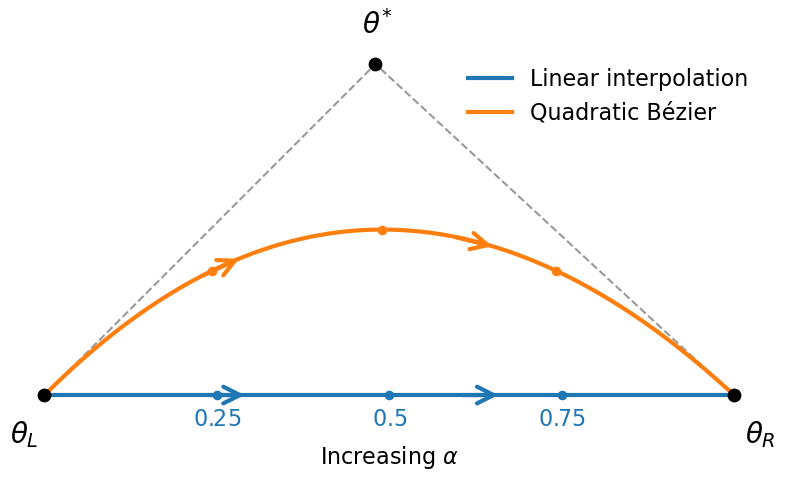

In [ ]:
# illustrative plot code

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Schematic endpoint models
# ----------------------------
theta_L = np.array([0.0, 0.0])
theta_R = np.array([5.0, 0.0])
theta_star = np.array([2.4, 2.4])   # illustrative control model

alpha = np.linspace(0, 1, 300)

# Linear interpolation
linear = np.outer(1 - alpha, theta_L) + np.outer(alpha, theta_R)

# Quadratic Bézier
bezier = (
    np.outer((1 - alpha) ** 2, theta_L)
    + np.outer(2 * alpha * (1 - alpha), theta_star)
    + np.outer(alpha ** 2, theta_R)
)

fig, ax = plt.subplots(figsize=(8, 5))

# ----------------------------
# Control polygon
# ----------------------------
ax.plot(
    [theta_L[0], theta_star[0], theta_R[0]],
    [theta_L[1], theta_star[1], theta_R[1]],
    "--",
    color="gray",
    linewidth=1.5,
    alpha=0.8,
)

# ----------------------------
# Paths
# ----------------------------
ax.plot(
    linear[:, 0],
    linear[:, 1],
    color="tab:blue",
    linewidth=3,
    label="Linear interpolation",
)

ax.plot(
    bezier[:, 0],
    bezier[:, 1],
    color="tab:orange",
    linewidth=3,
    label="Quadratic Bézier",
)

# ----------------------------
# Endpoint and control points
# ----------------------------
ax.scatter(
    theta_L[0], theta_L[1],
    s=80, color="black", zorder=5
)
ax.scatter(
    theta_R[0], theta_R[1],
    s=80, color="black", zorder=5
)
ax.scatter(
    theta_star[0], theta_star[1],
    s=80, color="black", zorder=5
)

ax.text(theta_L[0]-0.25, theta_L[1]-0.35, r"$\theta_L$", fontsize=20)
ax.text(theta_R[0]+0.08, theta_R[1]-0.35, r"$\theta_R$", fontsize=20)
ax.text(theta_star[0]-0.1, theta_star[1]+0.22, r"$\theta^{*}$", fontsize=20)

# ----------------------------
# Alpha markers
# ----------------------------
sample_alphas = [0.25, 0.5, 0.75]

for a in sample_alphas:

    # Linear
    p = (1-a)*theta_L + a*theta_R
    ax.scatter(
        p[0], p[1],
        color="tab:blue",
        s=35,
        zorder=6,
    )

    ax.text(
        p[0],
        p[1]-0.22,
        rf"${a}$",
        color="tab:blue",
        fontsize=16,
        ha="center",
    )

    # Bézier
    q = (
        (1-a)**2 * theta_L
        + 2*a*(1-a)*theta_star
        + a**2 * theta_R
    )

    ax.scatter(
        q[0], q[1],
        color="tab:orange",
        s=35,
        zorder=6,
    )
# ----------------------------
# Direction arrows (larger)
# ----------------------------
for idx in [70, 180]:

    ax.annotate(
        "",
        xy=linear[idx+18],
        xytext=linear[idx],
        arrowprops=dict(
            arrowstyle="->",
            color="tab:blue",
            lw=3,
            mutation_scale=30,
        ),
    )

    ax.annotate(
        "",
        xy=bezier[idx+18],
        xytext=bezier[idx],
        arrowprops=dict(
            arrowstyle="->",
            color="tab:orange",
            lw=3,
            mutation_scale=30,
        ),
    )

# Alpha label on Bézier
linear_mid = 0.5 * theta_L + 0.5 * theta_R

ax.text(
    linear_mid[0],
    linear_mid[1] - 0.5,
    r"Increasing $\alpha$",
    fontsize=16,
    ha="center",
)

# ----------------------------
# Appearance
# ----------------------------
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(frameon=False, loc="upper right",fontsize = 16)

plt.tight_layout()
plt.show()